In [ ]:
%pip install matplotlib pandas numpy scikit-learn

  Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [7]:
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, pairwise_distances, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Notebooks live in all_experiments/, so the course folder is one level up.
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "ML" / "all_datasets"

In [8]:
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.5.3
pandas: 3.0.6
Matplotlib: 3.11.2
scikit-learn: 1.9.1


In [10]:
df = pd.read_csv(DATA / "titanic_dataset.csv")
print("shape:", df.shape)
df.head()


shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
print("\nData types:\n", df.dtypes)
print("\nSurvival rate:\n", df["Survived"].value_counts(normalize=True))


Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Survival rate:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


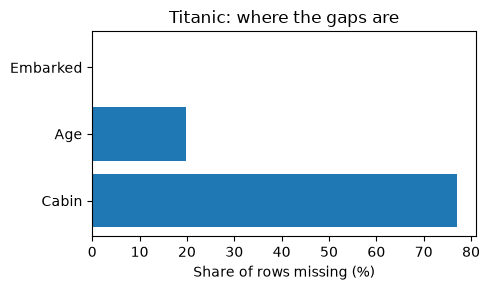

In [16]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(5, 3))
plt.barh(missing.index, missing.to_numpy() * 100)
plt.xlabel("Share of rows missing (%)")
plt.title("Titanic: where the gaps are")
plt.tight_layout()
plt.show()

In [19]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Other")
df["LogFare"] = np.log1p(df["Fare"])
df[["Name", "Title", "FamilySize", "IsAlone", "Fare", "LogFare"]].head()


,Name,Title,FamilySize,IsAlone,Fare,LogFare
0,"Braund, Mr. Owen Harris",Mr,2,0,7.2500,2.110213
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,71.2833,4.280593
2,"Heikkinen, Miss. Laina",Miss,1,1,7.9250,2.188856
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,53.1000,3.990834
4,"Allen, Mr. William Henry",Mr,1,1,8.0500,2.202765


In [18]:
print("\nTitle counts:\n", df["Title"].value_counts())


Title counts:
 Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


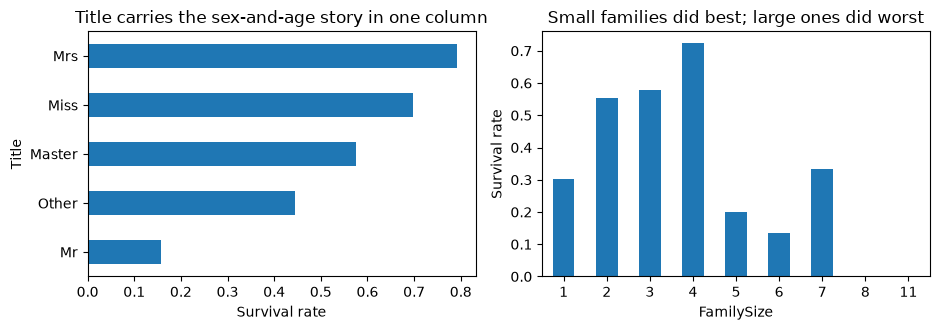

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
df.groupby("Title")["Survived"].mean().sort_values().plot.barh(ax=axes[0])
axes[0].set_xlabel("Survival rate")
axes[0].set_title("Title carries the sex-and-age story in one column")
df.groupby("FamilySize")["Survived"].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_ylabel("Survival rate")
axes[1].set_title("Small families did best; large ones did worst")
plt.tight_layout()
plt.show()

In [21]:
def make_preprocess(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])
y = df["Survived"]

feature_sets = {
    "raw columns": (["Age", "SibSp", "Parch", "Fare"], ["Pclass", "Sex", "Embarked"]),
    "raw + engineered": (["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"],
                        ["Pclass", "Sex", "Embarked", "Title"]),
}

for name, (num_cols, cat_cols) in feature_sets.items():
    X = df[num_cols + cat_cols]
    X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
    )
    model = Pipeline([
        ("preprocess", make_preprocess(num_cols, cat_cols)),
        ("model", LogisticRegression(max_iter=2000)),
    ]).fit(X_train, y_train)
    auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
    print(f"{name:18s} validation ROC AUC = {auc:.3f}")

raw columns        validation ROC AUC = 0.842
raw + engineered   validation ROC AUC = 0.872


In [23]:
cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")
feature_cols = [c for c in cancer.columns if c not in {"id", "diagnosis", "Unnamed: 32"}]
X_cancer = cancer[feature_cols]
three = ["area_mean", "texture_mean", "smoothness_mean"]
X_cancer[three].describe().loc[["mean", "std"]].round(3)

,area_mean,texture_mean,smoothness_mean
mean,654.889,19.290,0.096
std,351.914,4.301,0.014


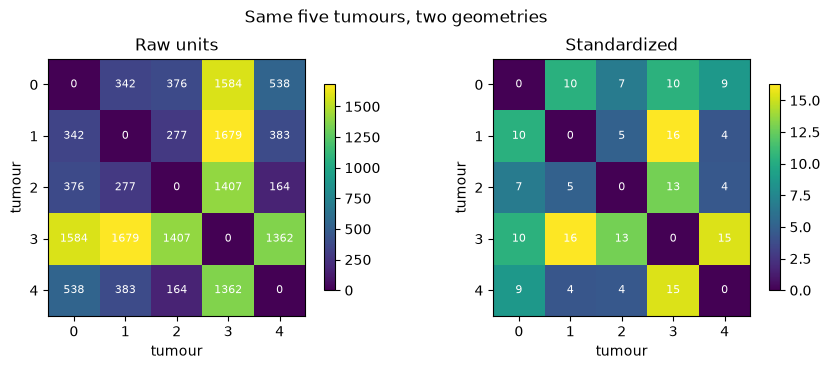

In [24]:
raw = pairwise_distances(X_cancer.iloc[:5], metric="euclidean")
X_scaled = StandardScaler().fit_transform(X_cancer)
scaled = pairwise_distances(X_scaled[:5], metric="euclidean")
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, matrix, title in [(axes[0], raw, "Raw units"), (axes[1], scaled, "Standardized")]:
    im = ax.imshow(matrix, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("tumour")
    ax.set_ylabel("tumour")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Same five tumours, two geometries")
plt.tight_layout()
plt.show()

In [25]:
students = pd.read_csv(DATA / "student_performance_dataset.csv")
print("shape:", students.shape, " missing:", students.isna().sum().sum(),
" duplicates:", students.duplicated().sum())
target = "G3"
leaky = ["G1", "G2"]
X_s = students.drop(columns=[target] + leaky)
y_s = students[target]
s_num = X_s.select_dtypes(include="number").columns.tolist()
s_cat = X_s.select_dtypes(exclude="number").columns.tolist()
print(len(s_num), "numeric and", len(s_cat), "text features available at enrolment")
Xs_train, Xs_valid, ys_train, ys_valid = train_test_split(X_s, y_s, test_size=0.25, random_state=42)

shape: (649, 33)  missing: 0  duplicates: 0
13 numeric and 17 text features available at enrolment


In [27]:
def evaluate(pipeline, X_tr, X_va, label):
    pipeline.fit(X_tr, ys_train)
    mae = mean_absolute_error(ys_valid, pipeline.predict(X_va))
    print(f"{label:32s} validation MAE = {mae:.3f} grade points")
    return mae
results = {}
results["all 30 features"] = evaluate(Pipeline([
        ("preprocess", make_preprocess(s_num, s_cat)),
        ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "all 30 features")

results["SelectKBest, k=10"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("select", SelectKBest(f_regression, k=10)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "SelectKBest, k=10")

lasso = Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("model", Lasso(alpha=0.1)),
])

results["lasso (selects itself)"] = evaluate(lasso, Xs_train, Xs_valid, "lasso (selects itself)")

leak_num = s_num + ["G2"]
results["all 30 + G2 (leakage)"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(leak_num, s_cat)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train.assign(G2=students.loc[Xs_train.index, "G2"]),
Xs_valid.assign(G2=students.loc[Xs_valid.index, "G2"]), "all 30 + G2 (leakage)")

all 30 features                  validation MAE = 2.181 grade points
SelectKBest, k=10                validation MAE = 2.139 grade points
lasso (selects itself)           validation MAE = 2.077 grade points
all 30 + G2 (leakage)            validation MAE = 0.762 grade points


lasso kept 19 of 56 encoded columns


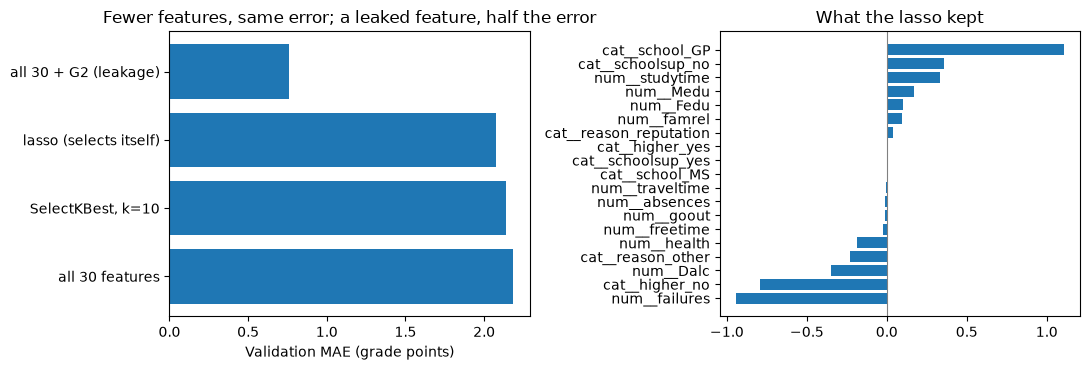

In [28]:
coefs = pd.Series(lasso.named_steps["model"].coef_,
index=lasso.named_steps["preprocess"].get_feature_names_out())
kept = coefs[coefs != 0].sort_values()
print(f"lasso kept {len(kept)} of {len(coefs)} encoded columns")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(list(results), list(results.values()))
axes[0].set_xlabel("Validation MAE (grade points)")
axes[0].set_title("Fewer features, same error; a leaked feature, half the error")
axes[1].barh(kept.index, kept.values)
axes[1].axvline(0, color="grey", linewidth=0.8)
axes[1].set_title("What the lasso kept")
plt.tight_layout()
plt.show()